## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os
import gc
import optuna
import pandas as pd
import numpy as np
from xgboost import XGBRanker, plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_holdout_split, XGBOOST_DATAFRAMES
from Challenge.utils import evaluate_recommender_xgboost
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback
from Challenge.hyper_tuning import ModelOptimizer

Running on local — storage at: /home/luigi/RecSys


/home/luigi/RecSys/Challenge/hyper_tuning.py:75: ExperimentalWarning: WilcoxonPruner is experimental (supported from v3.6.0). The interface can change in the future.
  def create_study(self, study_name, direction="maximize", load_if_exists=True, pruner=optuna.pruners.WilcoxonPruner()):
/home/luigi/RecSys/Challenge/hyper_tuning.py:107: ExperimentalWarning: WilcoxonPruner is experimental (supported from v3.6.0). The interface can change in the future.
  def create_and_optimize_study(self, study_name, objective_function, n_trials=50, direction="maximize", load_if_exists=True, pruner=optuna.pruners.WilcoxonPruner()):


## **Load Data**

In [4]:
np.random.seed(0xdead)

In [5]:
_, URM_outer = load_holdout_split()

In [6]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_OOF.parquet")

X_train = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,Label,EASE_R_Score,EASE_R_RankPosition,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,13,0,0,0,0,0,0,0.146634,106,...,2.763314,646,539,59,0.084832,0.081167,0.221003,77,413,1541.376587
1,0,5706,0,0,0,1,1,0,0.180238,58,...,2.756729,827,1427,10,0.191343,0.202138,0.577017,72,485,1429.055542
2,0,5766,0,0,1,1,1,0,0.305060,16,...,2.756729,351,1050,16,0.273811,0.139576,0.503647,72,2895,1429.055542
3,0,5830,0,0,0,0,0,0,0.162575,75,...,2.777495,412,1056,20,0.230950,0.167745,0.525276,72,1731,1429.055542
4,0,5956,0,0,0,0,0,0,0.241022,31,...,2.803360,43,47,10,0.289829,0.098583,0.472416,72,1454,1429.055542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23176689,27094,640,0,0,0,1,1,0,0.275289,76,...,4.523964,84,51,17,0.359248,0.152304,0.757386,221,2377,874.778259
23176690,27094,797,0,0,0,0,0,0,0.247680,96,...,4.458327,214,356,19,0.349893,0.228300,0.704917,221,615,874.778259
23176691,27094,868,0,0,0,0,0,0,0.316601,55,...,4.585932,706,1181,48,0.239673,0.137379,0.441403,221,6416,874.778259
23176692,27094,101,0,0,0,0,0,0,0.396964,33,...,4.503058,67,64,7,0.413890,0.196016,0.665027,221,576,818.176453


In [7]:
if not X_train['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train = X_train.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='snappy',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [8]:
# -------------------------------------------------------------------------
# 4. Prepare XGBoost Inputs on the SUBSET
# -------------------------------------------------------------------------

assert X_train['UserID'].is_monotonic_increasing, "Training set is not sorted by UserID!"

# Group Calculation (Must be done on the subset)
groups = X_train.groupby("UserID").size().values

# Target
y_train = X_train["Label"]

# Drop metadata to create Feature Matrix
X_train = X_train.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')

# Categorical handling
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')

assert groups.sum() == X_train.shape[0], "Group sum mismatch!"

In [9]:
X_train.columns

Index(['top_10', 'top_20', 'top_30', 'top_40', 'top_50', 'EASE_R_Score',
       'EASE_R_RankPosition', 'SLIMElasticNet_Score',
       'SLIMElasticNet_RankPosition', 'MultVAE_Score', 'MultVAE_RankPosition',
       'MatrixFactorization_WARP_Score',
       'MatrixFactorization_WARP_RankPosition', 'IALS_Score',
       'IALS_RankPosition', 'RP3beta_Score', 'RP3beta_RankPosition',
       'P3alpha_Score', 'P3alpha_RankPosition', 'UserKNN_cosine_Score',
       'UserKNN_cosine_RankPosition', 'UserKNN_tversky_Score',
       'UserKNN_tversky_RankPosition', 'ItemKNN_cosine_Score',
       'ItemKNN_cosine_RankPosition', 'ItemKNN_tversky_Score',
       'ItemKNN_tversky_RankPosition', 'SLIMElasticNet_MaxSim',
       'SLIMElasticNet_MeanSim', 'SLIMElasticNet_StdSim',
       'SLIMElasticNet_MatchCount', 'RP3beta_MaxSim', 'RP3beta_MeanSim',
       'RP3beta_StdSim', 'RP3beta_MatchCount', 'User_Cluster', 'Item_Cluster',
       'Cluster_Interaction', 'User_Cluster_Dist', 'Item_Cluster_Dist',
       'User_to

In [10]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_OOF.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_val[col] = X_val[col].astype('category')

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_OOF.parquet


,UserID,ItemID,top_10,top_20,top_30,top_40,top_50,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,User_to_ItemCluster_Dist,Mean_RankPosition,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity
0,0,86,0,0,0,0,0,0.158978,80,0.457685,...,2.869778,381,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524
1,0,227,0,0,1,1,1,0.230409,33,0.449216,...,2.907956,691,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524
2,0,275,0,0,0,0,0,0.061567,283,0.457007,...,2.855224,81,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524
3,0,282,0,0,0,1,1,0.182080,58,0.356088,...,2.841163,100,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524
4,0,291,0,0,0,0,0,0.119798,132,0.373464,...,2.869778,324,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,27094,6328,0,0,0,1,1,0.115149,263,0.577463,...,4.539614,78,72,11,0.379431,0.228762,0.806681,250,213,933.643982
2296114,27094,6516,0,1,1,1,1,0.448237,16,0.432170,...,4.409982,463,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982
2296115,27094,6620,0,0,0,0,0,0.311993,56,0.289841,...,4.494019,313,248,56,0.237791,0.118687,0.424300,250,396,933.643982
2296116,27094,6724,0,0,0,0,1,0.147140,199,0.557740,...,4.494019,204,240,17,0.315344,0.215339,0.724451,250,225,933.643982


In [11]:
# Reorder val columns to match training set
feature_cols = [c for c in X_train.columns if c != 'Label'] + ['UserID', 'ItemID']
X_val = X_val[feature_cols]

assert X_val['UserID'].is_monotonic_increasing, "Validation set is not sorted by UserID!"

In [12]:
# Ensure UserID and ItemID are integers for indexing
val_user_ids = X_val['UserID'].values
val_item_ids = X_val['ItemID'].values

# SCIPY TRICK: URM[rows, cols] returns a matrix of values for those specific pairs
# We convert it to a dense numpy array immediately
# Note: This requires URM_outer to be a CSR or CSC matrix
y_val = np.array(URM_outer[val_user_ids, val_item_ids]).squeeze()

# If URM is binary, y_val is now 0s and 1s. 
# If URM has ratings (1-5), y_val has ratings. For ranking, we usually want binary or weighted.
# Ensure it is 1D array
y_val = np.array(y_val).flatten()

# Calculate groups for validation set
val_feature_cols = [c for c in X_train.columns]
X_val_features = X_val[val_feature_cols]

val_groups = X_val.groupby("UserID").size().values
assert val_groups.sum() == X_val.shape[0], "Validation group sum mismatch!"

In [13]:
X_val

,top_10,top_20,top_30,top_40,top_50,EASE_R_Score,EASE_R_RankPosition,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity,UserID,ItemID
0,0,0,0,0,0,0.206471,47,0.158978,80,0.457685,...,776,37,0.191037,0.131878,0.457685,80,3378,1710.587524,0,86
1,0,0,1,1,1,0.322070,16,0.230409,33,0.449216,...,1101,12,0.259972,0.192477,0.596722,80,2310,1710.587524,0,227
2,0,0,0,0,0,0.121145,142,0.061567,283,0.457007,...,80,21,0.263086,0.149934,0.485854,80,1043,1710.587524,0,275
3,0,0,0,1,1,0.226636,33,0.182080,58,0.356088,...,116,7,0.260711,0.181357,0.626083,80,1819,1710.587524,0,282
4,0,0,0,0,0,0.144223,91,0.119798,132,0.373464,...,746,13,0.220234,0.139970,0.415816,80,2854,1710.587524,0,291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296113,0,0,0,1,1,0.284526,80,0.115149,263,0.577463,...,72,11,0.379431,0.228762,0.806681,250,213,933.643982,27094,6328
2296114,0,1,1,1,1,0.389765,28,0.448237,16,0.432170,...,1333,14,0.406694,0.234251,0.685544,250,2956,933.643982,27094,6516
2296115,0,0,0,0,0,0.218922,137,0.311993,56,0.289841,...,248,56,0.237791,0.118687,0.424300,250,396,933.643982,27094,6620
2296116,0,0,0,0,1,0.218773,138,0.147140,199,0.557740,...,240,17,0.315344,0.215339,0.724451,250,225,933.643982,27094,6724


## **Baseline**

In [14]:
recommender = XGBoostRerankerRecommender(None, X_val) # Pre process X_val for faster evaluation

In [15]:
params = {
    'n_estimators': 3000, 
    'objective': 'rank:ndcg',
    'grow_policy': 'depthwise',
    'reg_alpha': 0.015,       # From Trial 101
    'reg_lambda': 0.15,       # From Trial 101
    'subsample': 0.88,        # From Trial 101
    'colsample_bytree': 0.80, # From average of top trials
    'learning_rate': 0.03860112636082628,
    'max_depth': 12,
    'min_child_weight': 41
}

XGB_model = XGBRanker(
    **params,
    enable_categorical=True,
    tree_method="hist",
    
    n_jobs=-1,
    random_state=42,
    
    # Early stopping
    callbacks=[
        ProgressCallback(total_trees=params['n_estimators'], period=50)
    ],
    eval_metric=["map@20"],
    early_stopping_rounds=100
)


# Fit XG boost reranker
XGB_model.fit(
    X_train, y_train, group=groups,
    eval_set=[(X_val_features, y_val)],
    eval_group=[val_groups],
    verbose=False
)
print(f"Training ended at tree {XGB_model.best_iteration}")
print(f"Best Score: {XGB_model.best_score}")

# Set the XGB model in the recommender
recommender.XGB_model = XGB_model

# Evaluate
score = evaluate_recommender_xgboost(recommender, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

[Training] Tree 50/3000 | [validation_0] map@20: 0.24080
[Training] Tree 100/3000 | [validation_0] map@20: 0.24115
[Training] Tree 150/3000 | [validation_0] map@20: 0.24151
[Training] Tree 200/3000 | [validation_0] map@20: 0.24155
[Training] Tree 250/3000 | [validation_0] map@20: 0.24145
Training ended at tree 152
Best Score: 0.2416034450673117
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:04<00:00,  5.78it/s]

Validation Score (RECALL@20): 0.2959


In [16]:
score

np.float64(0.2959379229571121)

In [15]:
params = {
    'n_estimators': 3000, 
    'objective': 'rank:ndcg',
    'grow_policy': 'depthwise',
    'reg_alpha': 0.015,
    'reg_lambda': 0.15,
    'subsample': 0.88,
    'colsample_bytree': 0.80,
    'learning_rate': 0.02,
    'max_depth': 12,
    'min_child_weight': 60
}

XGB_model = XGBRanker(
    **params,
    enable_categorical=True,
    tree_method="hist",
    
    n_jobs=-1,
    random_state=42,
    
    # Early stopping
    callbacks=[
        ProgressCallback(total_trees=params['n_estimators'], period=50)
    ],
    eval_metric=["map@20"],
    early_stopping_rounds=100
)


# Fit XG boost reranker
XGB_model.fit(
    X_train, y_train, group=groups,
    eval_set=[(X_val_features, y_val)],
    eval_group=[val_groups],
    verbose=False
)
print(f"Training ended at tree {XGB_model.best_iteration}")
print(f"Best Score: {XGB_model.best_score}")

# Set the XGB model in the recommender
recommender.XGB_model = XGB_model

# Evaluate
score = evaluate_recommender_xgboost(recommender, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score}")

[Training] Tree 50/3000 | [validation_0] map@20: 0.24072
[Training] Tree 100/3000 | [validation_0] map@20: 0.24088
[Training] Tree 150/3000 | [validation_0] map@20: 0.24117
[Training] Tree 200/3000 | [validation_0] map@20: 0.24141
[Training] Tree 250/3000 | [validation_0] map@20: 0.24148
[Training] Tree 300/3000 | [validation_0] map@20: 0.24146
[Training] Tree 350/3000 | [validation_0] map@20: 0.24154
[Training] Tree 400/3000 | [validation_0] map@20: 0.24144
Training ended at tree 312
Best Score: 0.24163607779922477
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:09<00:00,  3.09it/s]

Validation Score (RECALL@20): 0.29608745005415543


In [ ]:
params = {
    'n_estimators': 3000, 
    'objective': 'rank:ndcg',
    'grow_policy': 'depthwise',
    'reg_alpha': 0.015,
    'reg_lambda': 0.15,
    'subsample': 0.88,
    'colsample_bytree': 0.80,
    'learning_rate': 0.01,
    'max_depth': 12,
    'min_child_weight': 75
}

XGB_model = XGBRanker(
    **params,
    enable_categorical=True,
    tree_method="hist",
    
    n_jobs=-1,
    random_state=42,
    
    # Early stopping
    callbacks=[
        ProgressCallback(total_trees=params['n_estimators'], period=50)
    ],
    eval_metric=["map@20"],
    early_stopping_rounds=100
)


# Fit XG boost reranker
XGB_model.fit(
    X_train, y_train, group=groups,
    eval_set=[(X_val_features, y_val)],
    eval_group=[val_groups],
    verbose=False
)
print(f"Training ended at tree {XGB_model.best_iteration}")
print(f"Best Score: {XGB_model.best_score}")

# Set the XGB model in the recommender
recommender.XGB_model = XGB_model

# Evaluate
score = evaluate_recommender_xgboost(recommender, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score}")

[Training] Tree 50/3000 | [validation_0] map@20: 0.24078
[Training] Tree 100/3000 | [validation_0] map@20: 0.24075
[Training] Tree 150/3000 | [validation_0] map@20: 0.24085
[Training] Tree 200/3000 | [validation_0] map@20: 0.24107
[Training] Tree 250/3000 | [validation_0] map@20: 0.24126
[Training] Tree 300/3000 | [validation_0] map@20: 0.24161
[Training] Tree 350/3000 | [validation_0] map@20: 0.24155
[Training] Tree 400/3000 | [validation_0] map@20: 0.24180
[Training] Tree 450/3000 | [validation_0] map@20: 0.24185
[Training] Tree 500/3000 | [validation_0] map@20: 0.24204
[Training] Tree 550/3000 | [validation_0] map@20: 0.24213
[Training] Tree 600/3000 | [validation_0] map@20: 0.24215
[Training] Tree 650/3000 | [validation_0] map@20: 0.24213
Training ended at tree 588
Best Score: 0.242201510868704
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:15<00:00,  1.78it/s]

Validation Score (RECALL@20): 0.2959601708447512


## **Optimization**

In [29]:
optimizer = ModelOptimizer("XG_Boost_subset")
STUDY_NAME = XGBoostRerankerRecommender.RECOMMENDER_NAME + "subset_final_v3"

In [30]:
from optuna.pruners import MedianPruner
from optuna.integration.xgboost import XGBoostPruningCallback

def objective_function_all_in(optuna_trial: optuna.trial.Trial) -> float:
    
    params = {
        # --- FIXED BASE ---
        'n_estimators': 5000,         # High cap to allow low LR to converge
        'objective': 'rank:ndcg',
        'grow_policy': 'depthwise',
        
        # --- THE "BIG 3" TUNING (Narrow & Focused) ---
        # We force low LR to ensure >500 trees
        'learning_rate': optuna_trial.suggest_float('learning_rate', 0.008, 0.025, log=True),
        # Your manual run was 60. We search around that.
        'min_child_weight': optuna_trial.suggest_int('min_child_weight', 50, 90),
        # You proved 12 is great. We check neighbors just in case.
        'max_depth': optuna_trial.suggest_int('max_depth', 11, 13),
        
        # --- THE "FINE TUNING" KNOBS (Re-enabled) ---
        # Now that we have full data, let's see if we need more/less sampling
        'subsample': optuna_trial.suggest_float('subsample', 0.75, 0.95),
        'colsample_bytree': optuna_trial.suggest_float('colsample_bytree', 0.75, 0.95),
        
        # Regularization: Critical for "squeezing" the last bit.
        # We search a log scale to see if we need tiny (0.01) or moderate (2.0) reg.
        'reg_alpha': optuna_trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda': optuna_trial.suggest_float('reg_lambda', 0.01, 5.0, log=True),
    }

    XGB_model = XGBRanker(
        **params,
        enable_categorical=True,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        callbacks=[
            # CRITICAL: Prune trials that are clearly worse than the median
            # This saves hours of compute!
            XGBoostPruningCallback(optuna_trial, "validation_0-map@20"),
            ProgressCallback(total_trees=params['n_estimators'], period=50)
        ],
        eval_metric=["map@20"],
        early_stopping_rounds=150  # Increased patience for low LR
    )

    # FIT on FULL DATA
    XGB_model.fit(
        X_train, y_train, group=groups,
        eval_set=[(X_val_features, y_val)],
        eval_group=[val_groups],
        verbose=False
    )
    
    # Evaluate
    recommender.XGB_model = XGB_model
    score = evaluate_recommender_xgboost(recommender, at=20, URM_validation=URM_outer)

    optimizer.log_folds([score], params)
    
    return score

In [31]:
optuna_study = optimizer.create_study(
    study_name=STUDY_NAME,
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=100, interval_steps=50),
)

[I 2025-12-04 11:02:46,798] A new study created in RDB with name: XGBoostRerankerRecommendersubset_final_v3


In [32]:
optuna_study = optimizer.optimize(
    objective_function=objective_function_all_in,
    n_trials=50
)

  0%|          | 0/50 [00:00<?, ?it/s]

[Training] Tree 50/5000 | [validation_0] map@20: 0.24023
[Training] Tree 100/5000 | [validation_0] map@20: 0.24072
[Training] Tree 150/5000 | [validation_0] map@20: 0.24092
[Training] Tree 200/5000 | [validation_0] map@20: 0.24129
[Training] Tree 250/5000 | [validation_0] map@20: 0.24154
[Training] Tree 300/5000 | [validation_0] map@20: 0.24155
[Training] Tree 350/5000 | [validation_0] map@20: 0.24147
[Training] Tree 400/5000 | [validation_0] map@20: 0.24150
[Training] Tree 450/5000 | [validation_0] map@20: 0.24177
[Training] Tree 500/5000 | [validation_0] map@20: 0.24182
[Training] Tree 550/5000 | [validation_0] map@20: 0.24177
[Training] Tree 600/5000 | [validation_0] map@20: 0.24168
[Training] Tree 650/5000 | [validation_0] map@20: 0.24157
Evaluating on 27095 users available in the XGBoost model...


Eval Batches: 100%|██████████| 28/28 [00:12<00:00,  2.27it/s]


[I 2025-12-04 11:38:30,343] Trial 0 finished with value: 0.2959323079349473 and parameters: {'learning_rate': 0.01916741944821613, 'min_child_weight': 66, 'max_depth': 11, 'subsample': 0.8513334115515899, 'colsample_bytree': 0.9149784249439616, 'reg_alpha': 0.08125343417043426, 'reg_lambda': 0.019225830042935863}. Best is trial 0 with value: 0.2959323079349473.
[Training] Tree 50/5000 | [validation_0] map@20: 0.23977
[Training] Tree 100/5000 | [validation_0] map@20: 0.23991
[Training] Tree 150/5000 | [validation_0] map@20: 0.24007
[Training] Tree 200/5000 | [validation_0] map@20: 0.24037
[Training] Tree 250/5000 | [validation_0] map@20: 0.24036
[Training] Tree 300/5000 | [validation_0] map@20: 0.24054
[Training] Tree 350/5000 | [validation_0] map@20: 0.24065
[Training] Tree 400/5000 | [validation_0] map@20: 0.24092
[Training] Tree 450/5000 | [validation_0] map@20: 0.24116
[Training] Tree 500/5000 | [validation_0] map@20: 0.24119
[Training] Tree 550/5000 | [validation_0] map@20: 0.24125

Eval Batches: 100%|██████████| 28/28 [00:12<00:00,  2.26it/s]


...

Eval Batches: 100%|██████████| 28/28 [00:11<00:00,  2.41it/s]


[I 2025-12-04 16:08:32,799] Trial 9 finished with value: 0.29607346770182674 and parameters: {'learning_rate': 0.01663494687086197, 'min_child_weight': 79, 'max_depth': 13, 'subsample': 0.7759364599906572, 'colsample_bytree': 0.8480380945337984, 'reg_alpha': 0.13829042388269522, 'reg_lambda': 0.20579730124732049}. Best is trial 9 with value: 0.29607346770182674.
[Training] Tree 50/5000 | [validation_0] map@20: 0.24045
[Training] Tree 100/5000 | [validation_0] map@20: 0.24081
[I 2025-12-04 16:14:51,896] Trial 10 pruned. Trial was pruned at iteration 100.
[Training] Tree 50/5000 | [validation_0] map@20: 0.24047
[Training] Tree 100/5000 | [validation_0] map@20: 0.24074
[I 2025-12-04 16:20:44,307] Trial 11 pruned. Trial was pruned at iteration 100.
[Training] Tree 50/5000 | [validation_0] map@20: 0.24077
[Training] Tree 100/5000 | [validation_0] map@20: 0.24069
[Training] Tree 150/5000 | [validation_0] map@20: 0.24107
[I 2025-12-04 16:29:41,138] Trial 12 pruned. Trial was pruned at iterati

Eval Batches: 100%|██████████| 28/28 [00:12<00:00,  2.19it/s]


[I 2025-12-04 17:39:29,218] Trial 18 finished with value: 0.2959625529388626 and parameters: {'learning_rate': 0.014796720623989602, 'min_child_weight': 77, 'max_depth': 13, 'subsample': 0.7911049804306042, 'colsample_bytree': 0.8720660205728442, 'reg_alpha': 0.019084690376546188, 'reg_lambda': 0.48748415415879215}. Best is trial 9 with value: 0.29607346770182674.
[Training] Tree 50/5000 | [validation_0] map@20: 0.24029
[Training] Tree 100/5000 | [validation_0] map@20: 0.24068
[I 2025-12-04 17:45:13,657] Trial 19 pruned. Trial was pruned at iteration 100.
[Training] Tree 50/5000 | [validation_0] map@20: 0.24036
[Training] Tree 100/5000 | [validation_0] map@20: 0.24065
[I 2025-12-04 17:51:10,249] Trial 20 pruned. Trial was pruned at iteration 100.
[Training] Tree 50/5000 | [validation_0] map@20: 0.24030
[Training] Tree 100/5000 | [validation_0] map@20: 0.24012
[I 2025-12-04 17:57:07,769] Trial 21 pruned. Trial was pruned at iteration 100.
[Training] Tree 50/5000 | [validation_0] map@20:

KeyboardInterrupt: 

In [33]:
optuna_study = optimizer.create_study(STUDY_NAME)

[I 2025-12-04 18:32:21,362] Using an existing study with name 'XGBoostRerankerRecommendersubset_final_v3' instead of creating a new one.


In [34]:
print("Best Params:", optuna_study.best_params)
print("Best Score:", optuna_study.best_value)

Best Params: {'learning_rate': 0.01663494687086197, 'min_child_weight': 79, 'max_depth': 13, 'subsample': 0.7759364599906572, 'colsample_bytree': 0.8480380945337984, 'reg_alpha': 0.13829042388269522, 'reg_lambda': 0.20579730124732049}
Best Score: 0.29607346770182674


In [35]:
optuna.visualization.plot_optimization_history(optuna_study)

In [36]:
optuna.visualization.plot_param_importances(optuna_study)

In [37]:
optuna.visualization.plot_parallel_coordinate(optuna_study)

In [38]:
# Look at the top 10 trials params
optuna_study.trials_dataframe().sort_values(by='value', ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
9,9,0.296073,2025-12-04 15:35:27.140301,2025-12-04 16:08:32.785717,0 days 00:33:05.645416,0.848038,0.016635,13,79,0.138290,0.205797,0.775936,COMPLETE
4,4,0.296017,2025-12-04 13:09:48.498508,2025-12-04 14:00:51.844794,0 days 00:51:03.346286,0.911997,0.010569,12,83,1.363832,0.033217,0.801483,COMPLETE
6,6,0.295983,2025-12-04 14:21:51.141351,2025-12-04 15:23:52.069833,0 days 01:02:00.928482,0.867524,0.009349,12,67,0.200814,1.936855,0.752369,COMPLETE
18,18,0.295963,2025-12-04 17:04:54.661279,2025-12-04 17:39:29.209117,0 days 00:34:34.547838,0.872066,0.014797,13,77,0.019085,0.487484,0.791105,COMPLETE
0,0,0.295932,2025-12-04 11:02:49.234159,2025-12-04 11:38:30.329587,0 days 00:35:41.095428,0.914978,0.019167,11,66,0.081253,0.019226,0.851333,COMPLETE
2,2,0.295893,2025-12-04 12:18:07.023166,2025-12-04 12:41:05.035267,0 days 00:22:58.012101,0.831651,0.022358,12,61,0.037489,0.202323,0.805910,COMPLETE
3,3,0.295839,2025-12-04 12:41:05.093572,2025-12-04 13:09:48.446820,0 days 00:28:43.353248,0.789653,0.016548,11,76,0.215223,0.031823,0.812197,COMPLETE
5,5,0.295533,2025-12-04 14:00:51.909370,2025-12-04 14:21:51.086116,0 days 00:20:59.176746,0.928351,0.020986,13,80,0.120943,3.143895,0.939991,COMPLETE
1,1,0.294954,2025-12-04 11:38:30.391351,2025-12-04 12:18:06.961792,0 days 00:39:36.570441,0.931299,0.008174,11,66,2.874398,0.017786,0.774472,COMPLETE
14,14,0.241486,2025-12-04 16:35:30.867419,2025-12-04 16:47:09.476428,0 days 00:11:38.609009,0.752527,0.013990,12,73,0.586135,0.076837,0.831689,PRUNED


In [39]:
import optuna.visualization as vis

# 1. See where you haven't looked for the most important pair
# If you see empty white spaces in the high-performance colors, that's a gap.
vis.plot_contour(optuna_study, params=['learning_rate', 'min_child_weight'])

In [40]:
# 2. Check Depth vs Child Weight
vis.plot_contour(optuna_study, params=['max_depth', 'min_child_weight'])

In [41]:
df = optuna_study.trials_dataframe()

# Filter for completed trials
df = df[df.state == 'COMPLETE']

# Check how many times we actually tried the edge cases (e.g., depth 15 or 16)
high_depth_trials = df[df['params_max_depth'] >= 15]
print(f"Number of trials with depth 15+: {len(high_depth_trials)}")

# See the average score of those specific trials
if not high_depth_trials.empty:
    print(f"Best score in depth 15+ region: {high_depth_trials['value'].max()}")
    print(f"Average score in depth 15+ region: {high_depth_trials['value'].mean()}")
    
# Check the Low Learning Rate cluster performance
low_lr = df[df['params_learning_rate'] < 0.01]
print(f"Best score with LR < 0.01: {low_lr['value'].max()}")

Number of trials with depth 15+: 0
Best score with LR < 0.01: 0.29598303991598995


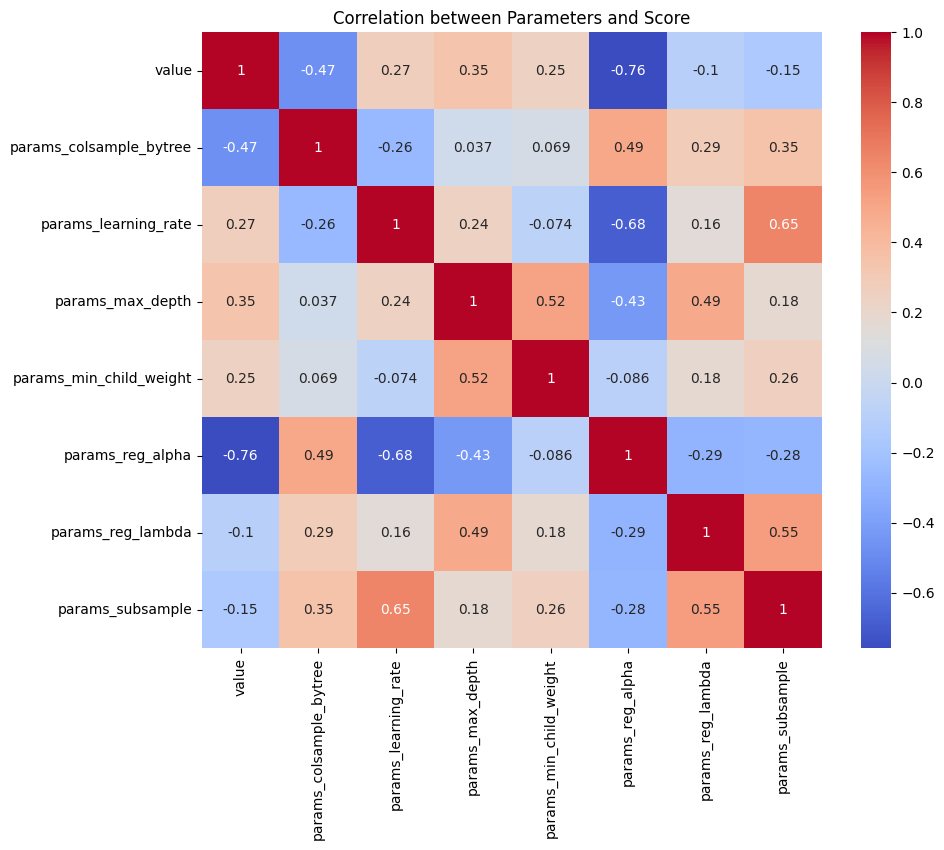

In [42]:
# Create a heatmap of parameter correlation
# This helps you see if parameters are fighting each other
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric parameter columns and the objective value
param_cols = [c for c in df.columns if 'params_' in c and df[c].dtype in [np.float64, np.int64]]
cols_to_plot = ['value'] + param_cols

plt.figure(figsize=(10,8))
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Parameters and Score")
plt.show()

In [43]:
STUDY_NAME = XGBoostRerankerRecommender.RECOMMENDER_NAME + "subset_final_v2"
optuna_study = optimizer.create_study(STUDY_NAME)

[I 2025-12-04 18:34:31,380] Using an existing study with name 'XGBoostRerankerRecommendersubset_final_v2' instead of creating a new one.


In [46]:
optuna_study.best_params

{'learning_rate': 0.01069123309545738,
 'min_child_weight': 87,
 'max_depth': 12,
 'subsample': 0.9223569068695108,
 'colsample_bytree': 0.8324436314210852,
 'reg_alpha': 0.5066160208194748,
 'reg_lambda': 1.474781469320333}

In [47]:
params = {
    'n_estimators': 5000,
    'objective': 'rank:ndcg',
    'grow_policy': 'depthwise',
    
    'learning_rate': 0.01069123309545738,
    'min_child_weight': 87,
    'max_depth': 12,
    'subsample': 0.9223569068695108,
    'colsample_bytree': 0.8324436314210852,
    'reg_alpha': 0.5066160208194748,
    'reg_lambda': 1.474781469320333
}

XGB_model = XGBRanker(
    **params,
    enable_categorical=True,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    callbacks=[
        ProgressCallback(total_trees=params['n_estimators'], period=50)
    ],
    eval_metric=["map@20"],
    early_stopping_rounds=150  # Increased patience for low LR
)

# FIT on FULL DATA
XGB_model.fit(
    X_train, y_train, group=groups,
    eval_set=[(X_val_features, y_val)],
    eval_group=[val_groups],
    verbose=False
)

# Evaluate
recommender.XGB_model = XGB_model
score = evaluate_recommender_xgboost(recommender, at=20, URM_validation=URM_outer)

score

[Training] Tree 50/5000 | [validation_0] map@20: 0.24050
[Training] Tree 100/5000 | [validation_0] map@20: 0.24067
[Training] Tree 150/5000 | [validation_0] map@20: 0.24089
[Training] Tree 200/5000 | [validation_0] map@20: 0.24095
[Training] Tree 250/5000 | [validation_0] map@20: 0.24126
[Training] Tree 300/5000 | [validation_0] map@20: 0.24140
[Training] Tree 350/5000 | [validation_0] map@20: 0.24151
[Training] Tree 400/5000 | [validation_0] map@20: 0.24179
[Training] Tree 450/5000 | [validation_0] map@20: 0.24188
[Training] Tree 500/5000 | [validation_0] map@20: 0.24189
[Training] Tree 550/5000 | [validation_0] map@20: 0.24202
[Training] Tree 600/5000 | [validation_0] map@20: 0.24208
[Training] Tree 650/5000 | [validation_0] map@20: 0.24204
[Training] Tree 700/5000 | [validation_0] map@20: 0.24221
[Training] Tree 750/5000 | [validation_0] map@20: 0.24223
[Training] Tree 800/5000 | [validation_0] map@20: 0.24225
[Training] Tree 850/5000 | [validation_0] map@20: 0.24222
[Training] Tree

Eval Batches: 100%|██████████| 28/28 [00:25<00:00,  1.11it/s]


np.float64(0.2962857385404153)